# GA5371 QC Vic/SA Gravity - SGL delivery 009

Author: Mark Dransfield 14 July 2022

## Introduction

This notebook summarises the QC of the DLV009 data delivery by SGL for the Vic/SA Gravity Survey flown for Geoscience Australia. The QC is performed under contract GA5371.

The project is SGL project GeoAus21.AUS and GA project number 5618.

The notebook is organised in line with the Technical Specifictions for the survey. Where data has failed a specification it is reported to SGL for rectification.

There were 45,107.9 line-km in DLV009, representing 13,312.4 km since the 31 795.5 km delivered in the last delivery (DLV007 and DLV008). From this, we must subtract 62.4 km for line 2657.4 which was re-flown. This leaves 13,250.0 km of new data approved by this analysis.

The rest of this first section is setting up the files for analysis, reporting a summary of the delivered data, and plotting a map of the lines flown against the plan.

### QC Colour Coding

Summary cells are coloured to quickly indicated status against QC. The colours are:

<div class="alert alert-block alert-success">
Delivery passed QC.
<div>

<div class="alert alert-block alert-info">
Delivery was not checked, or has unusual feature but is nevertheless acceptable.
<div>

<div class="alert alert-block alert-warning">
Delivery failed QC and problem has been reported for rectification.
<div>

<div class="alert alert-block alert-danger">
Delivery failed QC and problem might not be readily rectified. This is very rare.
<div>

#### Import required modules, and set filenames for data and plan.

In [5]:
%matplotlib widget
import sys
import importlib as im
import matplotlib.pyplot as plt
from pathlib import Path
local_docs = "/Users/markdransfield/"
src_path = local_docs + "Documents/GitHub/AirGravQC/src"
sys.path.insert(0, src_path)

import pointfiles as mhd
import qualityAnalysis as qc
import whizzPlot as wp
import gridfiles as erm

data_root = "/Users/markdransfield/Documents/GitHub/AirGravQC/examples/"
dx = Path(data_root + r'AG/DLV010/L1033700_94.xyz')
dh = dx.with_suffix('.hdf5')



#### Load `xyz` survey data into `hdf` survey file, and set attributes.

In [6]:
mhd.xyzToHDF(Path(dx), projectName='Victoria and South Australia Gravity')
block_name = 'DLV009'
mhd.updateProject(dh, acquirer='SGL', blockID=block_name)

mhd.updateCoordFrame(dh, lat='LAT', lon='LONG', x='MGA-X', y='MGA-Y', time='FTIME', alt='MGA-Z')
mhd.updateCoordFrame(dh, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

mhd.updateLineAttributes(dh, line_type='SGL_GA')

mhd.updateChannelAttributes(dh, 'ATMCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'B100s-267_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'B100s-267_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'B56s-267_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'B56s-267_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'EOTCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FA100s_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FA100s_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FA56s_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FA56s_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FACOR_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FACOR_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FTIME', units='s', chan_precision=2)
mhd.updateChannelAttributes(dh, 'FX', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FY', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'FZ', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'LALT', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'LAT', units='degree', chan_precision=7)
mhd.updateChannelAttributes(dh, 'LATCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'LONG', units='degree', chan_precision=7)
mhd.updateChannelAttributes(dh, 'MGA-X', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'MGA-Y', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'MGA-Z', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'MSL-Z', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'RALT', units='m', chan_precision=2)
mhd.updateChannelAttributes(dh, 'STATCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'TACOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(dh, 'V_EAST', units='m/s', chan_precision=3)
mhd.updateChannelAttributes(dh, 'V_NORTH', units='m/s', chan_precision=3)

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AG/DLV010/L1033700_94.xyz.
First few records are:
   /GNSS_Easting_GDA94MGA54 GNSS_Northing_GDA94MGA54 Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09 GNSS_Latitude_GDA94 GNSS_Longitude_GDA94 Elevation_GNSS_GRS80

   Line  1033700


  Found 1 header records
  Found 1 lines
  Found 6 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/AG/DLV010/L1033700_94.hdf5
Setting BlockID = DLV009 for L1033700_94.hdf5.
Setting Acquirer = SGL for L1033700_94.hdf5.
Changed CoordFrame attribute(s) for L1033700_94.hdf5.
Changed CoordFrame attribute(s) for L1033700_94.hdf5.

Setting Line attributes for L1033700_94.hdf5 according to the SGL_GA scheme.
  Line No.       Plan Line No.  Segment No.    Re-flight No.  
  1033700.0      1033700.0      0              0              


KeyError: "Unable to open object (object 'ATMCOR' doesn't exist)"

#### Report contents of survey data whizz file.

In [3]:
mhd.reportWhizz(dh)

Whizz Version 1.0
    Acquirer: SGL
    BlockID: DLV009
    ProjectName: Victoria and South Australia Gravity

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
323 lines: total distance flown [km] = 45,107.9

323 lines:
 ['2259.5', '2261.5', '2263.5', '2265.5', '2265.6', '2267.5', '2267.6', '2269.5', '2269.6', '2271.5', '2271.6', '2273.5', '2273.6', '2275.5', '2275.51', '2275.6', '2277.5', '2277.51', '2277.6', '2279.5', '2279.6', '2281.5', '2281.51', '2281.52', '2281.6', '2283.5', '2283.51', '2283.6', '2285.5', '2285.51', '2287.5', '2287.51', '2289.5', '2289.51', '2291.5', '2291.51', '2293.5', '2293.51', '2295.5', '2295.51', '2297.5', '2297.51', '2299.5', '2299.51', '2301.5', '2301.51', '2303.5', '2305.5', '2305.51', '2307.5', '2307.51', '2309.5', '2311.5', '2313.5', '2313.51', '2315.5', '2315.51', '231

Report contents of plan whizz File.

In [4]:
mhd.reportWhizz(w_plan_file)

Whizz Version 1.0
    ProjectName: GMEV Planned Drape

Coordinates
    AltitudeChannel: Drape_m
    LatitudeChannel: W84_Latitude_deg
    LongitudeChannel: W84_Longitude_deg
    XChannel: W84_UTM_55S_X_m
    YChannel: W84_UTM_55S_Y_m
1025 lines: total distance flown [km] = 187,256.8

1025 lines:
 ['2001.0', '2003.0', '2005.0', '2007.0', '2009.0', '201.0', '2011.0', '2013.0', '2015.0', '2017.0', '2019.0', '202.0', '2021.0', '2023.0', '2025.0', '2027.0', '2029.0', '203.0', '2031.0', '2033.0', '2035.0', '2037.0', '2039.0', '204.0', '2041.0', '2043.0', '2045.0', '2047.0', '2049.0', '205.0', '2051.0', '2053.0', '2055.0', '2057.0', '2059.0', '206.0', '2061.0', '2063.0', '2065.0', '2067.0', '2069.0', '207.0', '2071.0', '2073.0', '2075.0', '2077.0', '2079.0', '208.0', '2081.0', '2083.0', '2085.0', '2087.0', '2089.0', '209.0', '2091.0', '2093.0', '2095.0', '2097.0', '2099.0', '210.0', '2101.0', '2103.0', '2105.0', '2107.0', '2109.0', '211.0', '2111.0', '2113.0', '2115.0', '2117.0', '2119.0', '2

Make a lines map.

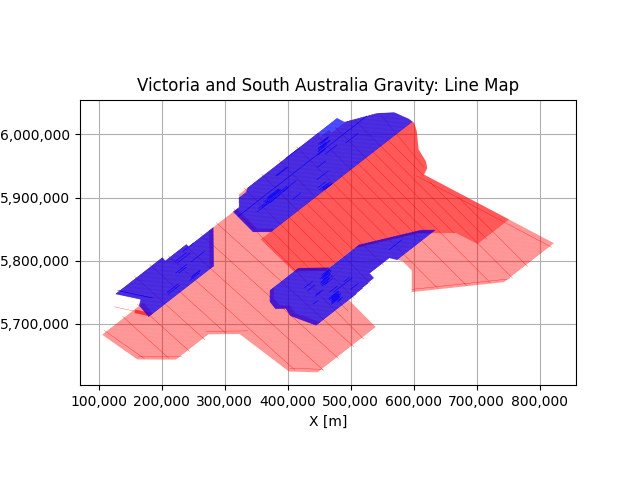

In [5]:
%matplotlib widget
wp.linesMap([dh], whizzPlanFile=w_plan_file)

A quick look at the Bouguer gravity. (Sadly reversed - whizz bug!)

32 bit precision


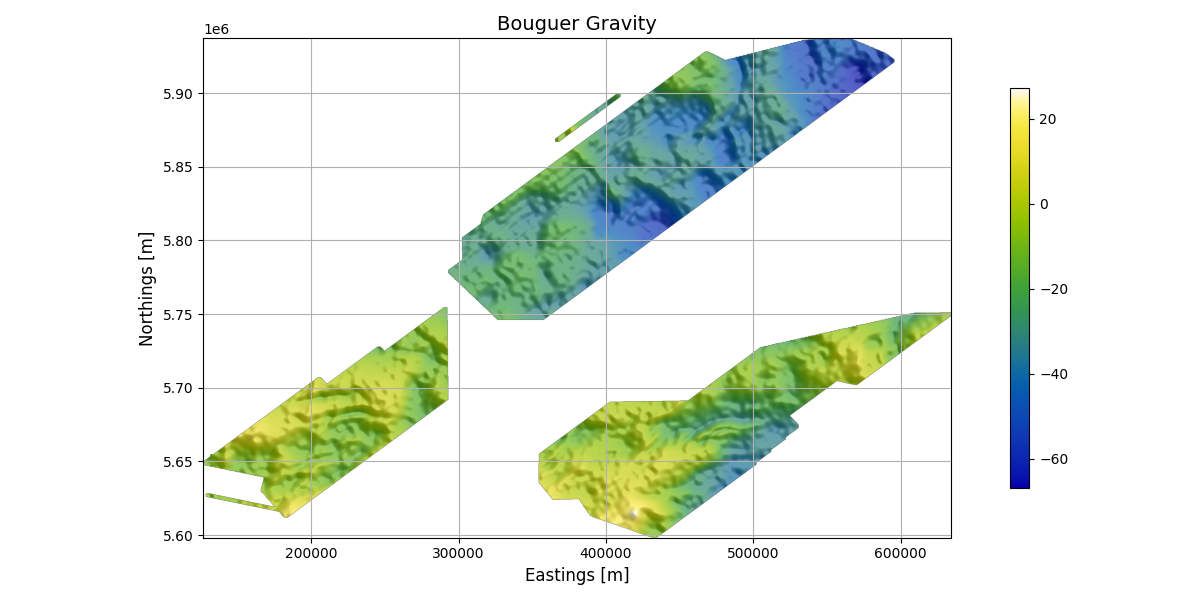

In [6]:
im.reload(erm)
erm.display_grid(boug_grid_path, 'Bouguer Gravity')

<div class="alert alert-block alert-success">
Data imported successfully.
<div>

In [7]:
im.reload(mhd)
mhd._distanceFlown(dh, lines=['2657.4'])

1 lines: total distance flown [km] = 62.4


(1, 62.35838724597255)

***

## Quality checks

The following sections describe the quality checks on the data. The data were delivered in XYZ format, an ASCII text fixed-width column format, separated by survey line number. All data were provided to a decimal precision better than nominal accuracy. Some of the following sections refer to an “aspect” and this means an aspect described in the survey contract.

Quality checks are reported by specification and are marked “pass” if all data passed, “accept” if the data were accepted despite minor deviations from specification or if the deviations were for safety reasons, “fail” if one or more lines require re-flying, or “NA” if the specification is not applicable to the delivered data.

### Survey Data

See the report for details.

#### Line direction
<div class="alert alert-block alert-success">
Line direction: PASS
<div>

limits: 42.0, 62.0
Line 2345.51: heading limit exceeded. Mean 52.08307354023806


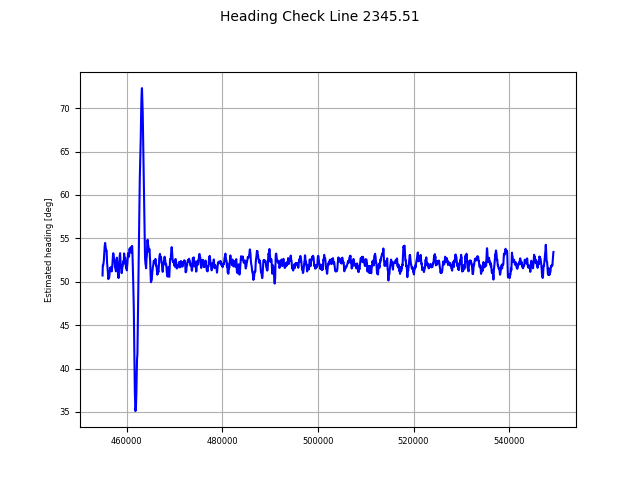

Line 256.3: heading limit exceeded. Mean -77.82612169821722


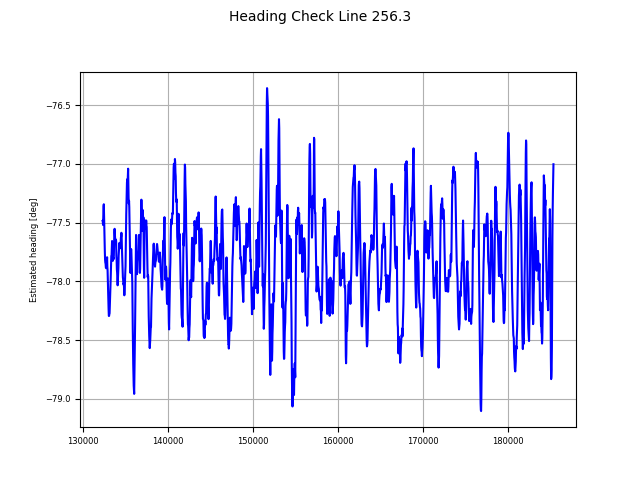

In [8]:
qc.checkHeading(dh, 52.0, tolerance=10)

L 2345.51 deviates around a smoke plume (power station). Accepted.
L 256.3 is good. The result reflects a bug in my s/w. Accepted

***

#### Line spacing
<div class="alert alert-block alert-success">
Line Spacing: PASS
<div>

In [9]:
qc.checkXYPlan(w_plan_file, dh, allowance=35.0, maxCounter=20)

Processing line 2259.5.
Processing line 2261.5.
Processing line 2263.5.
Processing line 2265.5.
Processing line 2265.6.
Processing line 2267.5.
Processing line 2267.6.
Processing line 2269.5.
Processing line 2269.6.
Processing line 2271.5.
Processing line 2271.6.
Processing line 2273.5.
Processing line 2273.6.
Processing line 2275.5.
Processing line 2275.51.
Processing line 2275.6.
Processing line 2277.5.
Processing line 2277.51.
Processing line 2277.6.
Processing line 2279.5.
Processing line 2279.6.
Processing line 2281.5.
Processing line 2281.51.
Processing line 2281.52.
Processing line 2281.6.
Processing line 2283.5.
Processing line 2283.51.
Processing line 2283.6.
Processing line 2285.5.
Processing line 2285.51.
Processing line 2287.5.
Processing line 2287.51.
Processing line 2289.5.
Processing line 2289.51.
Processing line 2291.5.
Processing line 2291.51.
Processing line 2293.5.
Processing line 2293.51.
Processing line 2295.5.
Processing line 2295.51.
Processing line 2297.5.
Proce

Of the 27 lines that strictly fail this spec, almost all are very minor exceedances and not worthy of re-flight. Four deserve a closer look, with peak exceedances greater than 10 m. These are:
2345.51 - deviation to avoid a smokestack. ACCEPT
2351.5 - deviation to avoid power station plume. Also partially recovered by 2351.51. ACCEPT
2661.3 - deviation for ATC (occurs right alongside Bacchus Marsh airport). ACCEPT
2707.3 - small and short exceedance near end of line and outside survey boundary. ACCEPT

#### Closest approach to terrain
<div class="alert alert-block alert-success">
Closest approach: PASS
<div>

In [10]:
im.reload(qc)
qc.checkClearance(dh, 'MGA-Z', 'DEM', 165.0, allowance=35.0, only_low=True)

Number of failed lines = 0.


#### Survey height against plan
<div class="alert alert-block alert-success">
Survey height: PASS
<div>

In [11]:
qc.checkVertPlan(w_plan_file, dh, planZ='Drape_m', measZ='MGA-Z', 
                 allowance=25.0, maxCounter=10, plot_flag=False)

L 2321.5 deviates more than 25.0 m for 136 fids (4138 m). Max exceedance = 46.9 m.
  From (460070 E, 5748673 N) to (463332 E, 5751220 N).
L 2343.51 deviates more than 25.0 m for 147 fids (4282 m). Max exceedance = 147.3 m.
  From (461942 E, 5764087 N) to (465317 E, 5766723 N).
L 2345.51 deviates more than 25.0 m for 191 fids (5802 m). Max exceedance = 153.2 m.
  From (543381 E, 5828831 N) to (538801 E, 5825269 N).
L 2605.4 deviates more than 25.0 m for 12 fids (370 m). Max exceedance = 4.4 m.
  From (516406 E, 5972622 N) to (516114 E, 5972394 N).
L 2605.4 deviates more than 25.0 m for 63 fids (1938 m). Max exceedance = 32.9 m.
  From (455728 E, 5925330 N) to (454198 E, 5924141 N).
L 2619.4 deviates more than 25.0 m for 24 fids (753 m). Max exceedance = 11.5 m.
  From (376813 E, 5872718 N) to (377415 E, 5873170 N).
L 2631.3 deviates more than 25.0 m for 22 fids (695 m). Max exceedance = 9.4 m.
  From (267310 E, 5794980 N) to (267866 E, 5795396 N).
L 2655.4 deviates more than 25.0 m for 

SGL report a longer list but they include deviations of short extent that I can accept. Of my list above, three (2619.4, 2667.41, 2673.41) are very minor and can be ignored. Seven are for unavoidable reasons (towers, smokestacks) or reasons (ATC requests) that will likely occur again if a re-fly is attempted; these are 2321.5, 2343.51, 2345.51, 2665.41, 2679.4, 2683.4, 2705.3.

This leaves 2605.4 (fire), 2631.3 (cloud), 2657.4 (cloud).<br>
> 2605.4 - clearance is ~650 m, so a ~65 m difference is equivalent to ~15 m at 165 m clearance. ACCEPT.<br>
2631.3 - exceedance length of 1235 m is only just over 1000 m. Maximum exceedance of 14.4 m is small. ACCEPT<br>
2657.4 - was re-flown in 2657.42. ACCEPT

L 2321.5 deviates more than 20.0 m for 148 fids (4503 m). Max exceedance = 51.9 m.
  From (459949 E, 5748581 N) to (463498 E, 5751352 N).
L 2343.51 deviates more than 20.0 m for 154 fids (4487 m). Max exceedance = 152.3 m.
  From (461829 E, 5763999 N) to (465365 E, 5766761 N).
L 2345.51 deviates more than 20.0 m for 201 fids (6103 m). Max exceedance = 158.2 m.
  From (543428 E, 5828868 N) to (538611 E, 5825121 N).
L 2605.4 deviates more than 20.0 m for 70 fids (2154 m). Max exceedance = 37.9 m.
  From (455777 E, 5925368 N) to (454077 E, 5924045 N).
L 2619.4 deviates more than 20.0 m for 52 fids (1622 m). Max exceedance = 16.5 m.
  From (376235 E, 5872247 N) to (377514 E, 5873244 N).
L 2631.3 deviates more than 20.0 m for 39 fids (1235 m). Max exceedance = 14.4 m.
  From (266959 E, 5794702 N) to (267939 E, 5795455 N).
L 2657.4 deviates more than 20.0 m for 86 fids (2828 m). Max exceedance = 123.2 m.
  From (351608 E, 5877178 N) to (353847 E, 5878905 N).
L 2665.41 deviates more than 20.0

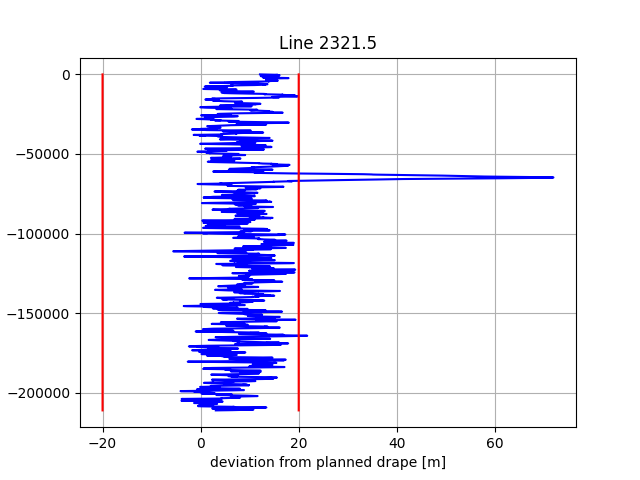

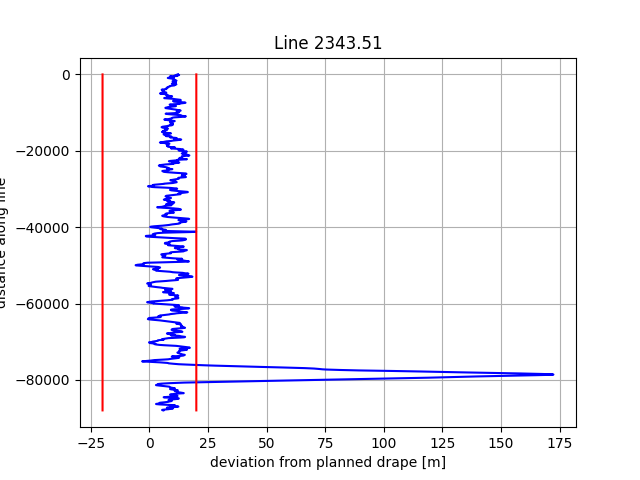

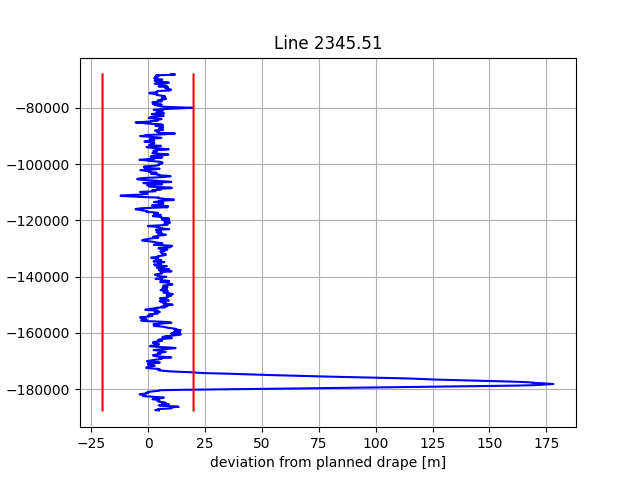

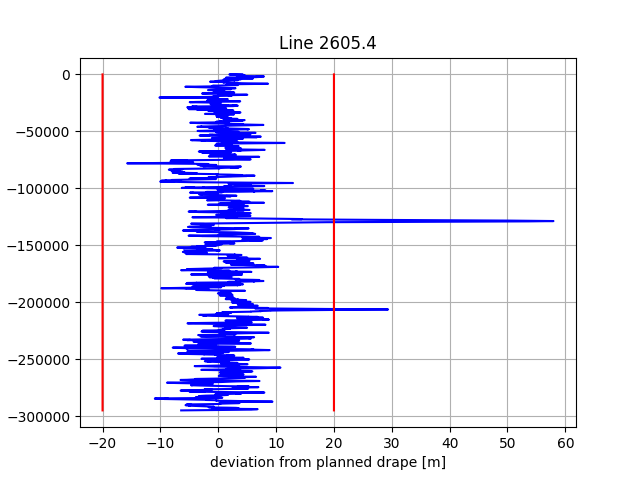

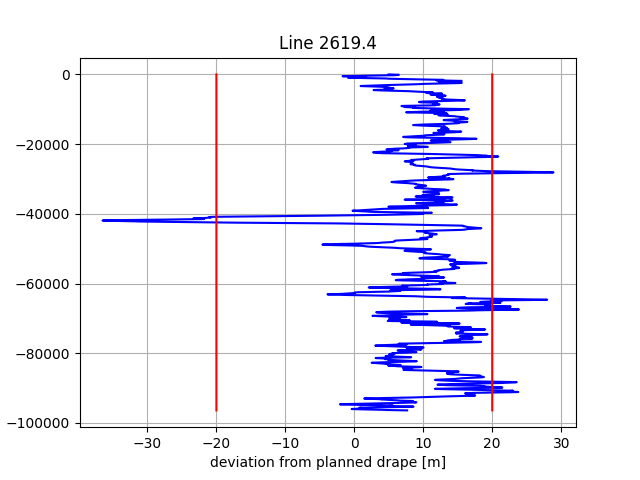

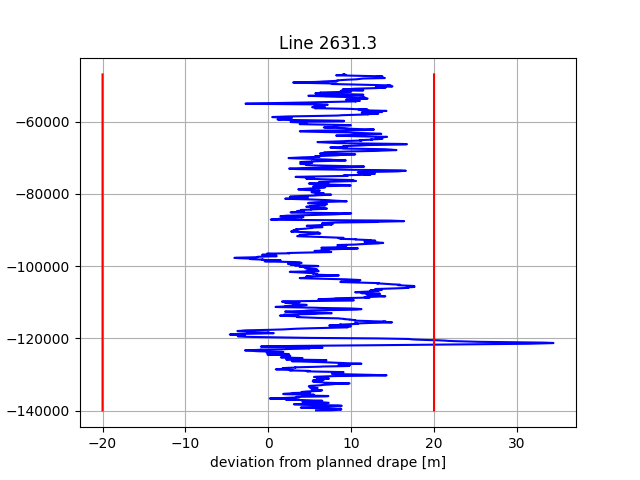

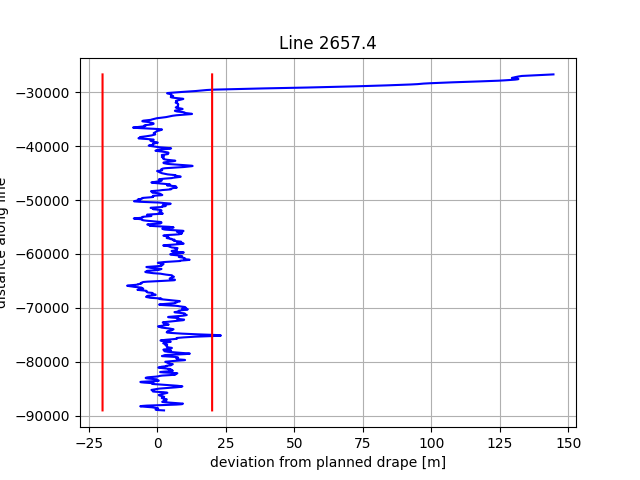

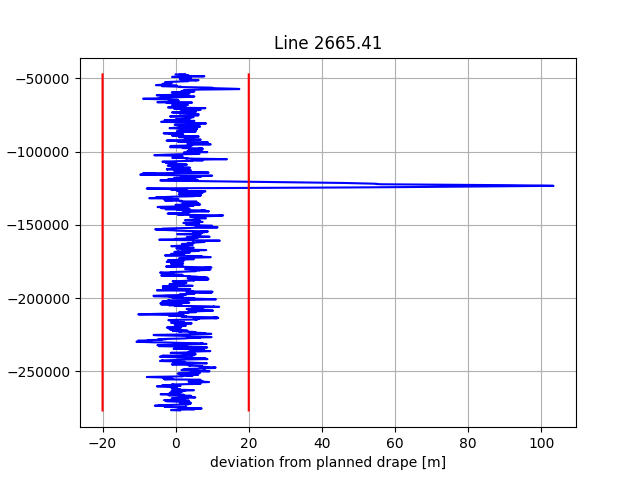

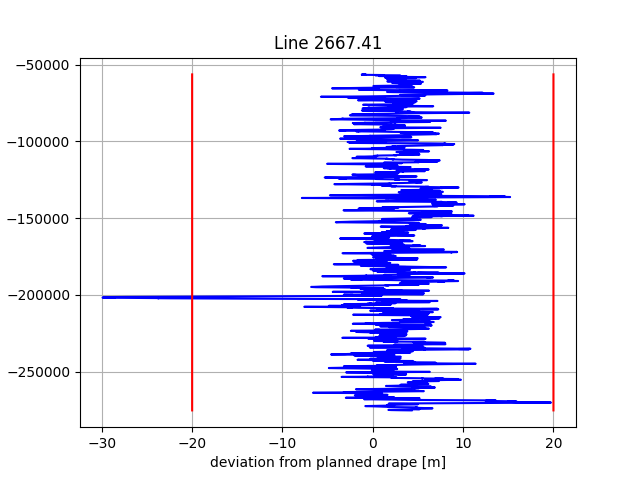

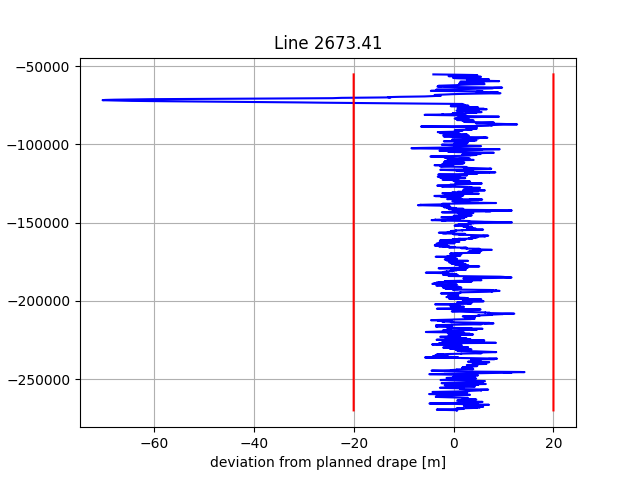

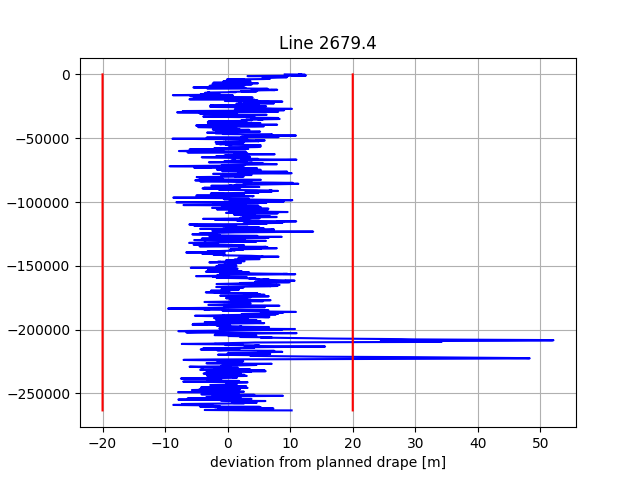

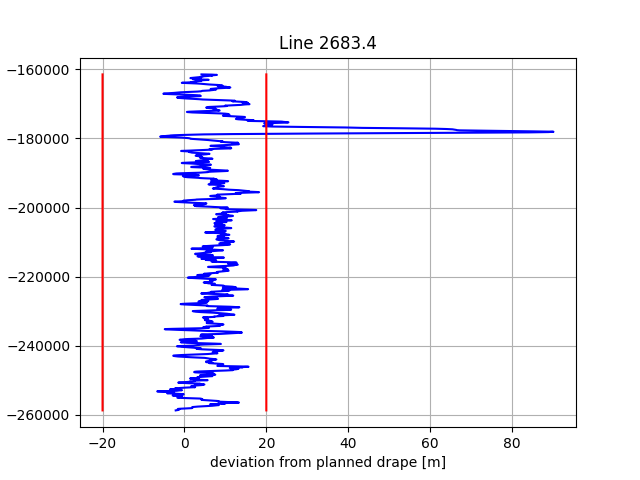

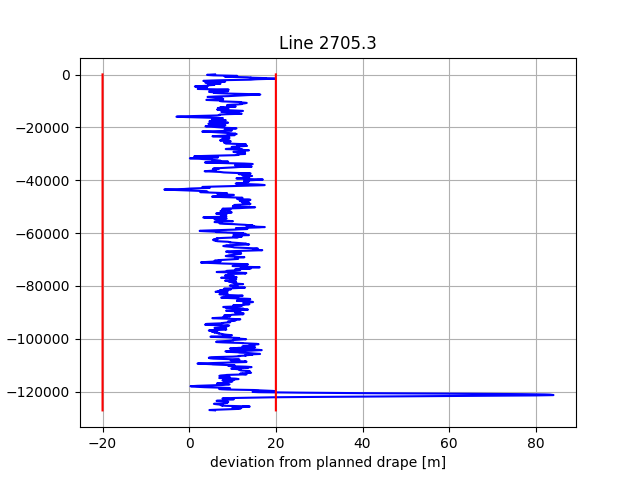

In [12]:
%matplotlib widget
qc.checkVertPlan(w_plan_file, dh, planZ='Drape_m', measZ='MGA-Z', allowance=20.0, maxCounter=35, plot_flag=True)

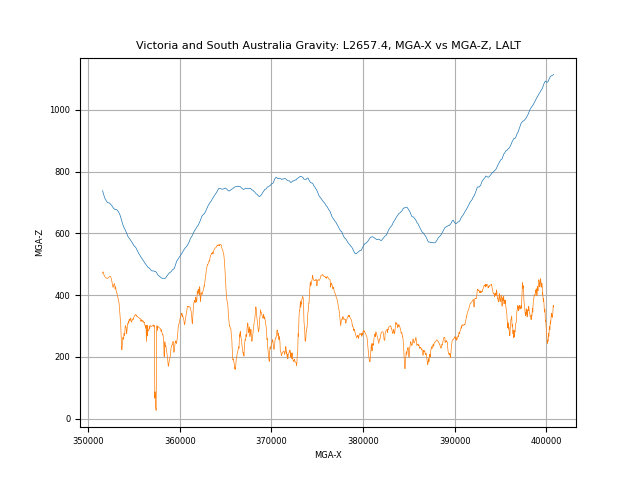

In [13]:
%matplotlib widget
wp.plotLineXChannels(dh, '2657.4', 'MGA-X', 'MGA-Z', 'LALT', xOffset=False)

#### Height difference at crossover
<div class="alert alert-block alert-info">
No control lines so NA
<div>

No control lines flown yet so NA.

#### Crossover intersections
<div class="alert alert-block alert-info">
No control lines so NA
<div>

No control lines flown yet so NA.

#### Minimum line length
<div class="alert alert-block alert-success">
Minimum line length: PASS
<div>

In [14]:
qc.checkLineLengths(dh, min_len=38.0)

Number failed lines = 0


#### Line padding
<div class="alert alert-block alert-success">
PASS
<div>

Checked by overlaying the plan (plan 9) over the actual flight lines. All good.

#### Overlaps
<div class="alert alert-block alert-success">
PASS
<div>

Repeat line 2275.5, 2275.51: overlap by 7829 m.
Repeat line 2277.5, 2277.51: overlap by 7841 m.
ERROR: Repeat line 2281.5, 2281.51: overlap 0 m < 7600.0.
Repeat line 2281.5, 2281.52: overlap by 15356 m.
Repeat line 2281.51, 2281.52: overlap by 15361 m.
Repeat line 2283.5, 2283.51: overlap by 15344 m.
Repeat line 2285.5, 2285.51: overlap by 15301 m.
Repeat line 2287.5, 2287.51: overlap by 14822 m.
Repeat line 2289.5, 2289.51: overlap by 15273 m.
Repeat line 2291.5, 2291.51: overlap by 19695 m.
Repeat line 2293.5, 2293.51: overlap by 11706 m.
Repeat line 2295.5, 2295.51: overlap by 15419 m.
Repeat line 2297.5, 2297.51: overlap by 15285 m.
Repeat line 2299.5, 2299.51: overlap by 15467 m.
Repeat line 2301.5, 2301.51: overlap by 18267 m.
Repeat line 2305.5, 2305.51: overlap by 25403 m.
Repeat line 2307.5, 2307.51: overlap by 36846 m.
Repeat line 2313.5, 2313.51: overlap by 10205 m.
Repeat line 2315.5, 2315.51: overlap by 15680 m.
Repeat line 2317.5, 2317.51: overlap by 8742 m.
Repeat line 2

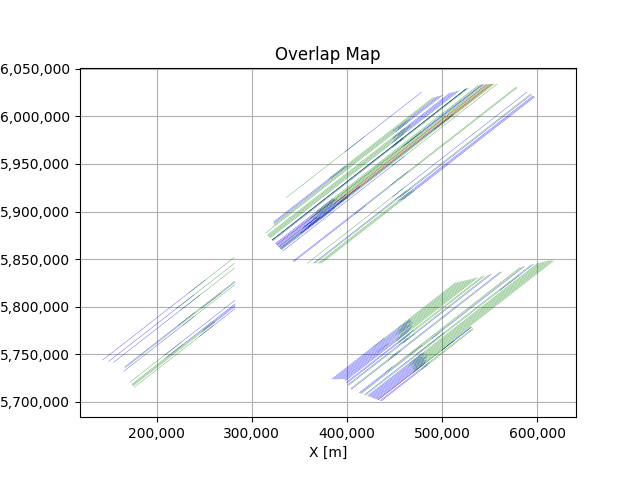

90 coincident lines found.


In [15]:
qc.checkOverlaps(dh)

Five lines had zero overlap with another on the same planned line:
> 2281.5, 2281.51 - both properly overlapped by .52<br>
2657.4, 2657.43 - 2657.4 completely re-flown by .42<br>
2659.41, 2659.42 - both properly overlapped by .40<br>
2663.41, 2663.42 - both properly overlapped by .40<br>
2669.4, 2669.41 - both properly overlapped by .42

#### Aircraft speed
<div class="alert alert-block alert-success">
PASS
<div>

In [2]:
qc.checkSpeeds(dh, nominalSpeed=60, maxLength=60)

NameError: name 'qc' is not defined

Nominal speed 60.0; allowed 52.5 : 67.5 for < 60.0 seconds.

 too slow for 72.5 secs > 60 allowed.
 too slow for 63.0 secs > 60 allowed.
Line 2621.3:
 ground speed < 52.5 for more than 60 s


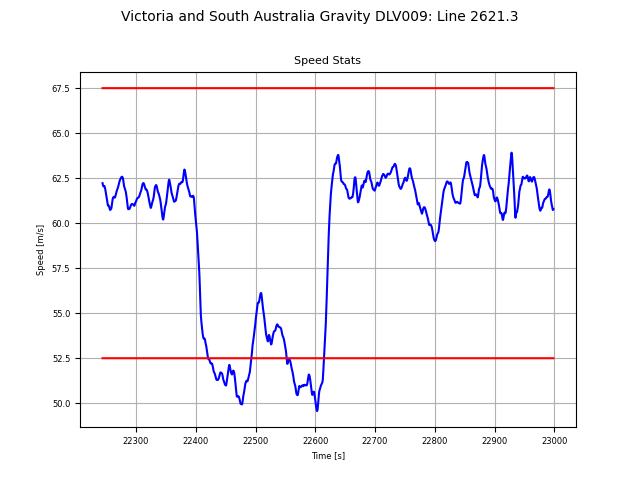

 1 high exceedances < 120 allowed.
 too slow for 70.5 secs > 60 allowed.
Line 2675.4:
 ground speed < 52.5 for more than 60 s


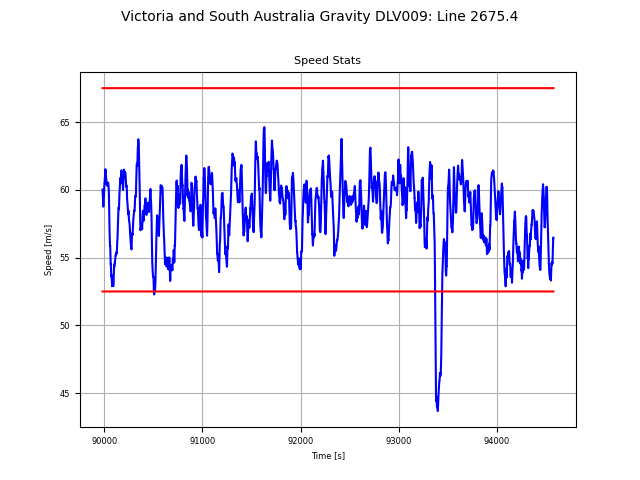

 too slow for 70.0 secs > 60 allowed.
Line 2681.41:
 ground speed < 52.5 for more than 60 s


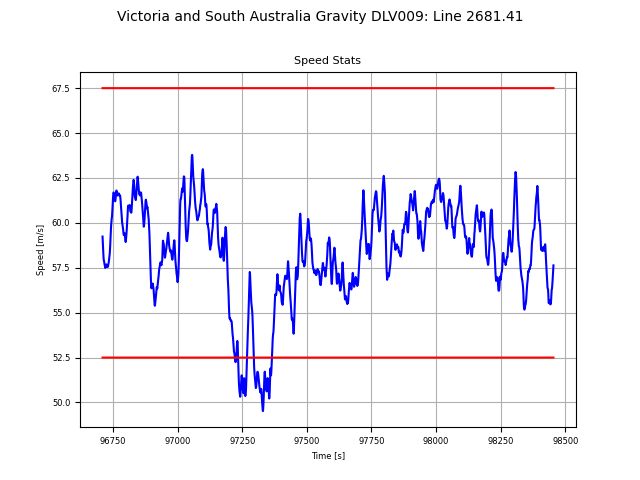

 too slow for 78.0 secs > 60 allowed.
Line 2685.31:
 ground speed < 52.5 for more than 60 s


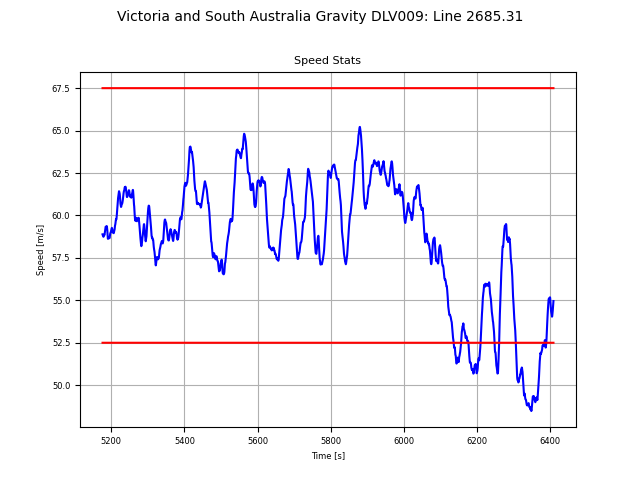

 too slow for 68.5 secs > 60 allowed.
Line 2693.4:
 ground speed < 52.5 for more than 60 s


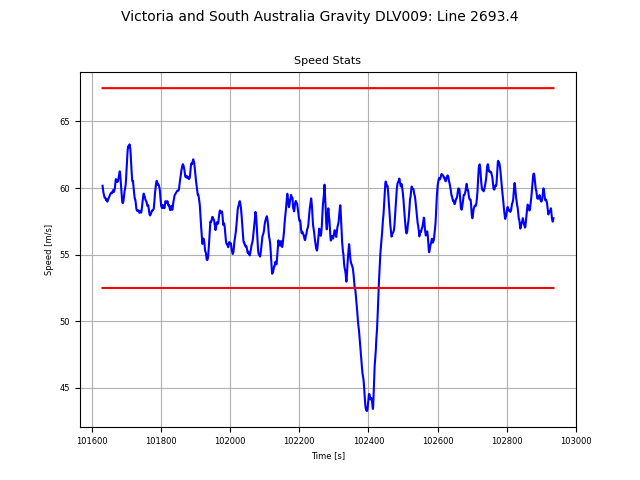

323 lines had some short exceedance(s).
5 lines failed for exceedance > allowed distance.


In [17]:
%matplotlib widget
qc.checkSpeeds(dh, nominalSpeed=60, maxLength=60, allowance=0.125, vel_north='V_NORTH', vel_east='V_EAST')

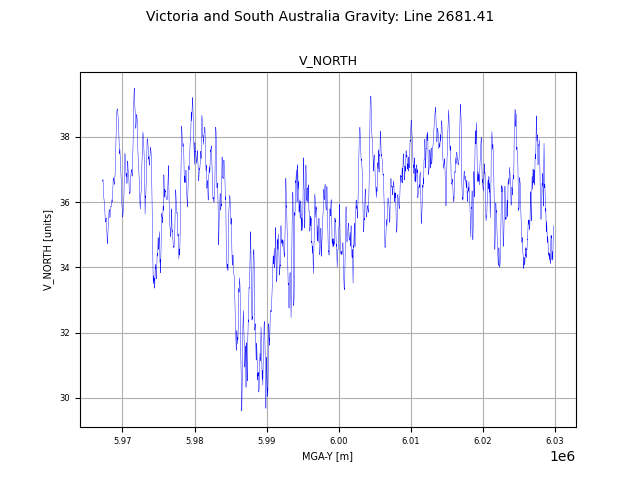

In [18]:
wp.plotLineChannel(dh, '2681.41', 'V_NORTH', x='MGA-Y', xOffset=False)

8 lines failed the spec: 2267.5, 2621.3, 2627.4, 2675.4, 2681.41, 2685.31, 2693.4, 2699.3.

Of these, 2267.5, 2627.4, 2675.4, 2693.4 were previously accepted in DLV003. 2681.41 was marked for re-flight.

2621.3 - 72 sec but two sections; associated with climbing to clear town of Batesford. ACCEPT
2681.41 - 70.5 sec, single section: ACCEPT
2685.31 - 78.5 sec but several sections; associated with climbing to clear town of Meredith. ACCEPT
2699.3 - within 12.5% of speed: ACCEPT

#### Data gaps
<div class="alert alert-block alert-success">
Pass
<div>

In [19]:
qc.checkSpikes(dh, fields=['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID', 'B56s-267_GRS80', 'EOTCOR', 'FA100s_GEOID', 'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FTIME', 'FX', 'FY', 'FZ', 'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z', 'STATCOR', 'TACOR', 'V_EAST', 'V_NORTH', 'YEAR'])


  2261.5; TACOR Extremum: 0.46 > 0.35 = 8.00 x STD of 0.04
  2263.5; TACOR Extremum: 0.24 > 0.19 = 8.00 x STD of 0.02
  2265.5; TACOR Extremum: 0.21 > 0.15 = 8.00 x STD of 0.02
  2277.5; TACOR Extremum: 0.13 > 0.13 = 8.00 x STD of 0.02
  2345.51; EOTCOR Extremum: 11.11 > 11.03 = 8.00 x STD of 1.38
  2345.51; LAT Extremum: 0.00 > 0.00 = 8.00 x STD of 0.00
  2345.51; LATCOR Extremum: 0.01 > 0.01 = 8.00 x STD of 0.00
  2345.51; MGA-Y Extremum: 9.93 > 9.04 = 8.00 x STD of 1.13
  2359.51; TACOR Extremum: 0.36 > 0.34 = 8.00 x STD of 0.04
  2601.4; FX Extremum: 53052.42 > 48823.68 = 8.00 x STD of 6102.96
  2631.3; TACOR Extremum: 0.40 > 0.35 = 8.00 x STD of 0.04
  2679.3; TACOR Extremum: 0.51 > 0.49 = 8.00 x STD of 0.06
  2683.42; LONG Extremum: 0.00 > 0.00 = 8.00 x STD of 0.00
  2683.42; MGA-X Extremum: 6.02 > 5.75 = 8.00 x STD of 0.72
  2689.3; TACOR Extremum: 0.63 > 0.54 = 8.00 x STD of 0.07
  2717.3; TACOR Extremum: 0.22 > 0.22 = 8.00 x STD of 0.03
  2719.4; TACOR Extremum: 0.68 > 0.65 =

None of the above spikes are of any concern and all are only just above the arbitrary (and non-contractual) criterion.

In [20]:
qc.checkGaps(dh)

Checking for all gaps in all 38 channels on all 323 lines.

0 lines failed.


In [21]:
qc.checkConstantSlope(dh, ['DOY', 'FLIGHT', 'FTIME', 'LINE', 'YEAR'])

All fields tested were either constant or of constant slope for all lines tested.


***

#### Check GNSS
<div class="alert alert-block alert-success">
Pass
<div>

In [22]:
qc.checkGNSS(dh, 'NSATS', 'PDOP', 'VDOP', 'HDOP', nsats_min=4, max_pdop=6, 
                  max_hdop=4, max_vdop=4)

In Victoria and South Australia Gravity, checked num sats, PDOP, VDOP and HDOP. Found 0 errors.


#### Check filtering
<div class="alert alert-block alert-success">
PASS
<div>

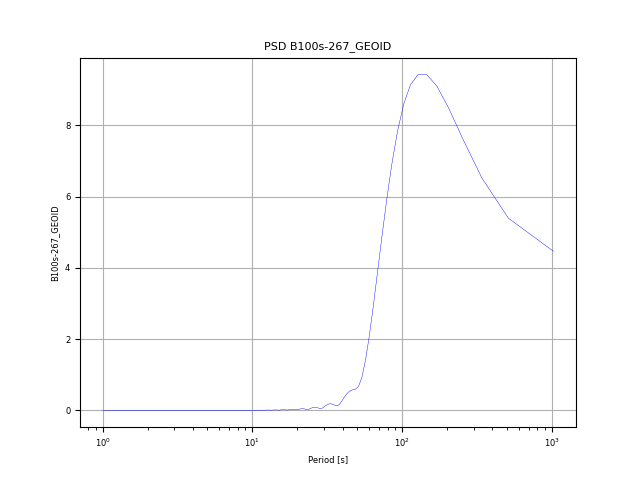

In [23]:
wp.psdLineChannel(dh, '2621.41', 'B100s-267_GEOID', plotTitle='PSD B100s-267_GEOID')

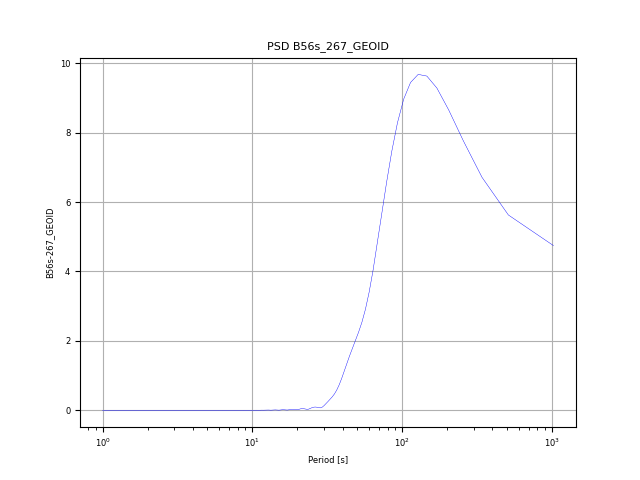

In [24]:
wp.psdLineChannel(dh, '2621.41', 'B56s-267_GEOID', plotTitle='PSD B56s_267_GEOID')

Grids of 56 and 100 s filtered data are consistent with expectations.<br>
Line profiles of Bouguer and free-air gravity have shortest distance between nearby peaks at ~80 sec (56 s filter) and ~140 sec (100 s filter), consistent with expectations.<br>
The power spectra are at least consistent with the expected filtering.

#### Check levelling
<div class="alert alert-block alert-success">
Pass
<div>

Reviewed grids. Minor levelling busts (up to $10 \mu m s^{-2}$) seen. Acceptable for field data pre- tie-line levelling.

#### Check static data
<div class="alert alert-block alert-success">
Pass
<div>

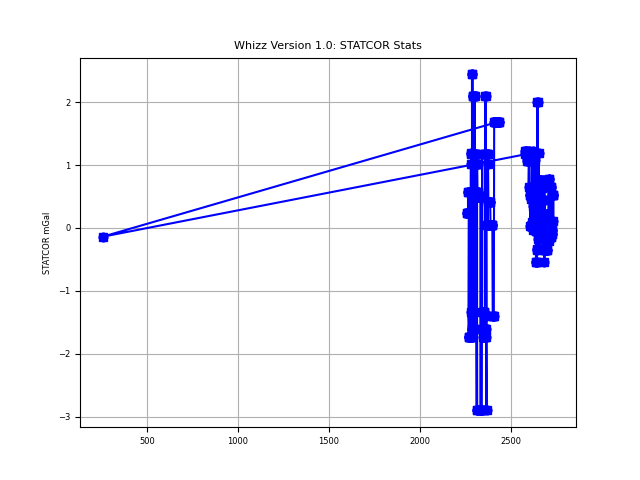

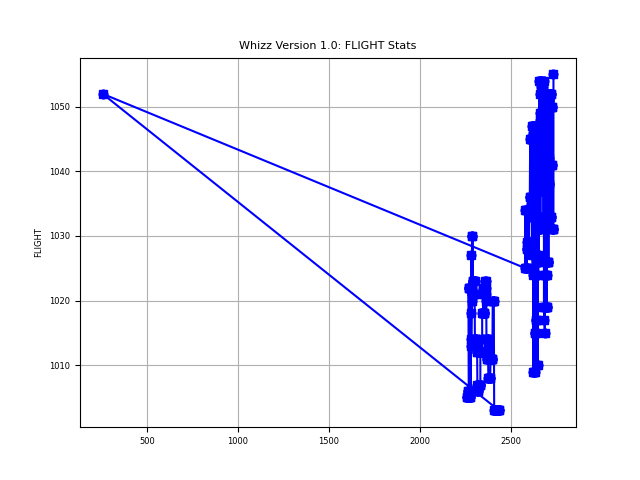

In [25]:
qc.allChanStats(dh, allChannels=['STATCOR', 'FLIGHT'])

Mean values of `STATCOR` are consistent with static readings pre- and post flights. The records of static data show variances well below the requirements.

#### Check all required deliverables present
<div class="alert alert-block alert-success">
PASS
<div>

The contract does not discriminate between field and final data but I am satisfied that all data required in field data has been delivered.

#### Supplied grid inspection
<div class="alert alert-block alert-success">
Pass
<div>

In [26]:
qc.checkErsHeaders(dh.parent)

Found 4 .ers files ...
in: /g/data/z67/nfm547/QAQC/AirGravQC_Package/examples/AG/DLV009
Comparing ERS files against F056a5000-fvd.ers.
[3961, 2371, 1, -999999.0, 'float32', 0, -999999.0, 'ieee-le', 'WGS84', 'SUTM55']
Checking file F056a5000.ers
  Checked OK.
Checking file B056a5000-fvd.ers
  Checked OK.
Checking file B056a5000.ers
  Checked OK.


#### Gridding data
<div class="alert alert-block alert-success">
PASS
<div>

The supplied grids and various grids generated from the database were visually checked. Generally, the grids were good and as expected. Two items of note:

The difference between laser altimeter and radar altimeter ranges shows a couple of odd features: a linear feature and a single isolated dot with differences > 100 m. Inexplicable to me. Some care will be needed to deal with these features before using the generated DEM in terrain corrections.

The gravity grids show some line-parallel striping. This is clearer on the Bouguer data than the free-air because of the dynamic range. It is clearer on the FVD, or on images shaded perpendicular to line direction. It is clearer on data gridded from the database using minimum curvature with small search radius. It is clearer in the north central part of Caravan Area B. Variations of over 1 mGal were seen across stripes so they are significant in amplitude. Many stripes are very long. They can be disappear as the dynamic range of the nearby signal increases but it is possible that some extend the entire length of a line. At least some stripes seem correlated with the gridded STATCOR field so they may represent gravimeter bias changes while airborne. It seems likely that significant improvement might be achieved by a simple amplitude shift. This should happen during tie-line levelling so not of concern in field data.

#### Atmospheric corrections
<div class="alert alert-block alert-success">
Atmospheric corrections: PASS
<div>

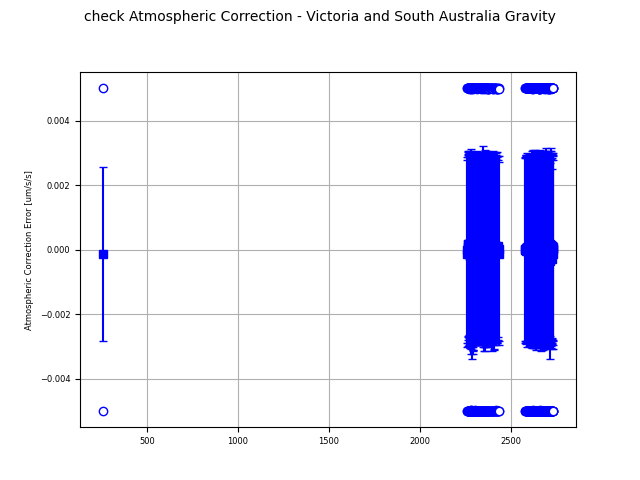

In [27]:
im.reload(qc)
qc.checkAtmosEffect(dh, 'ATMCOR', GRS80_height='MGA-Z')

#### Free air corrections
<div class="alert alert-block alert-success">
Free air corrections: PASS
<div>

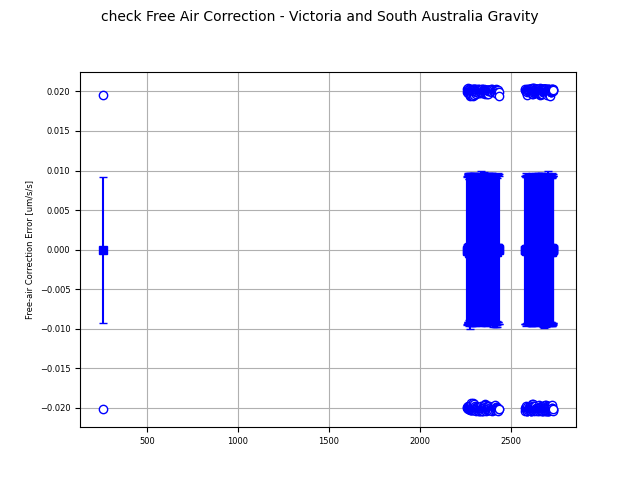

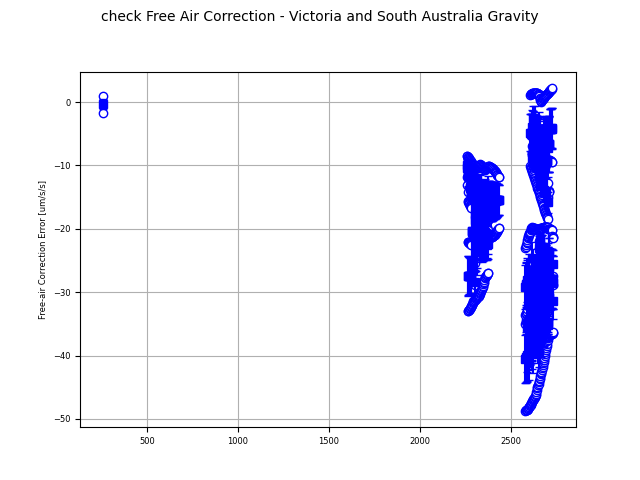

In [28]:
qc.checkFreeAirCorr(dh, 'FACOR_GRS80')
qc.checkFreeAirCorr(dh, 'FACOR_GEOID')

#### Eotvos corrections
<div class="alert alert-block alert-success">
Eotvos corrections: PASS
<div>

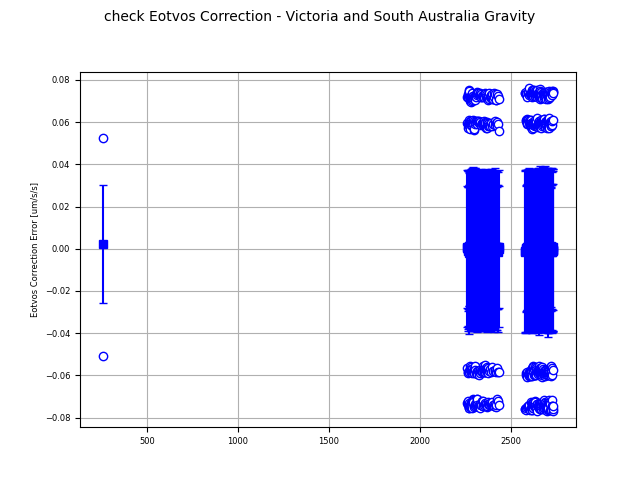

In [29]:
qc.checkEotvosCorr(dh, 'EOTCOR', east_vel='V_EAST', north_vel='V_NORTH')

#### Latitude corrections (normal gravity)
<div class="alert alert-block alert-success">
Latitude corrections: PASS
<div>

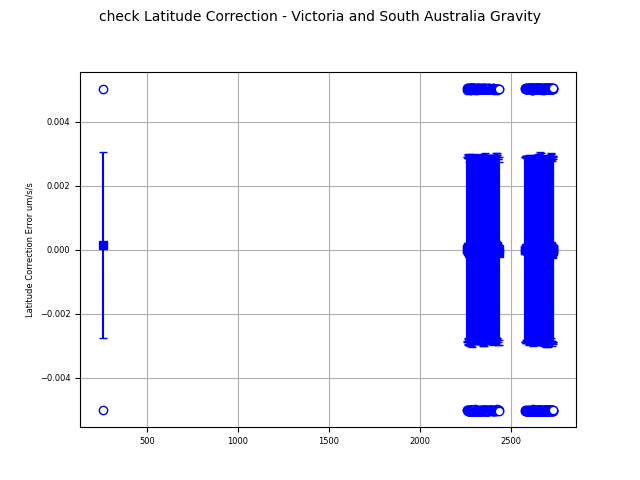

In [30]:
qc.checkLatCorr(dh, 'LATCOR')

#### Aircraft acceleration
<div class="alert alert-block alert-success">
Aircraft acceleration: PASS
<div>

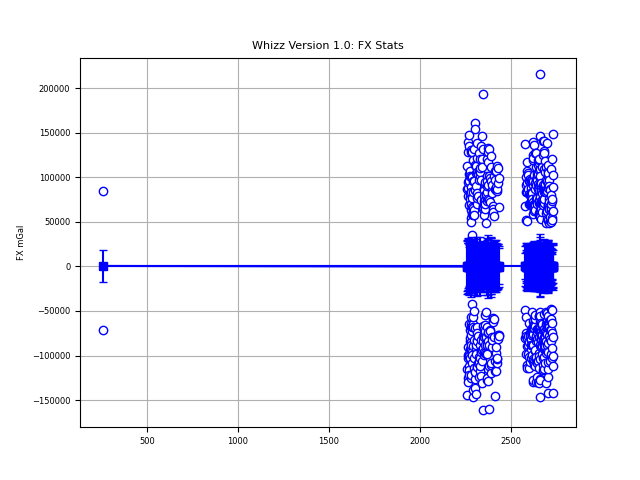

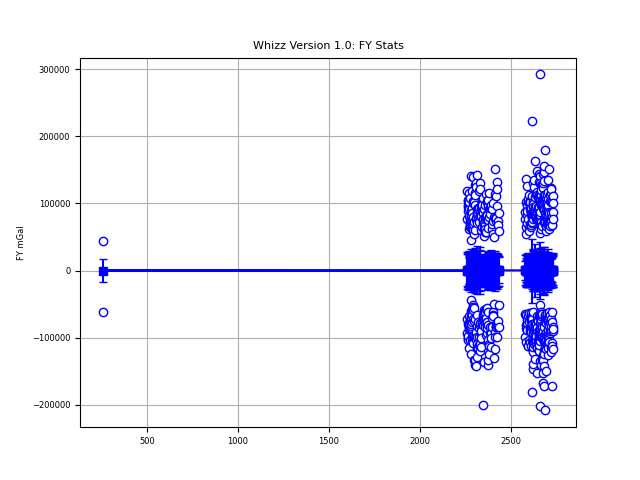

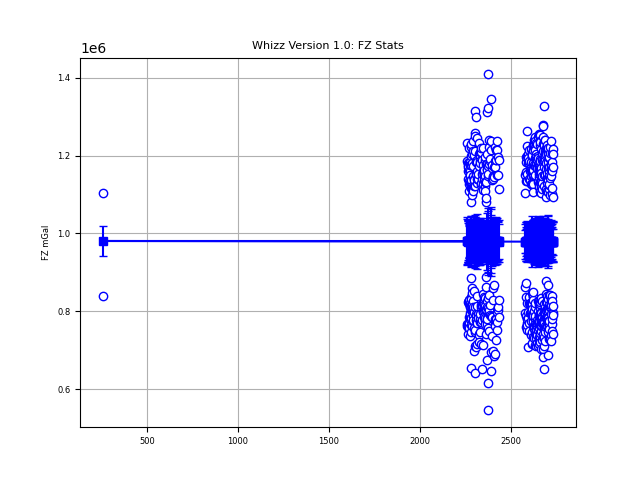

In [31]:
qc.allChanStats(dh,allChannels=['FX', 'FY', 'FZ'])

Means and variances are typical for airborne geophysical surveys.